# **Random Forests**


Random Forest is a powerful and widely used **ensemble learning** method built upon decision trees. Instead of relying on a single model, Random Forest constructs a collection (ensemble) of decision trees and aggregates their predictions to produce a final output.

This approach significantly improves predictive performance, robustness, and generalization compared to a single decision tree.


<br>

## **Ensemble Learning**

Ensemble learning is a fundamental paradigm in machine learning (not limited to decision trees) in which **multiple models** (often called **weak learners**) are combined to produce **a single, more powerful predictive model.**

An ensemble model combines these learners through an **aggregation** function.

The final output of this aggregation function depends on the task:
- Classification → **majority voting**
- Regression → **averaging**



## **Limitations of a Single Decision Tree**

Despite their interpretability, decision trees suffer from several key issues:

- **High Variance:** Small changes in the dataset can lead to entirely different trees.

- **Overfitting:** Deep trees tend to memorize training data rather than generalize.

- **Feature Dominance:** The root node is chosen deterministically and strongly influences the entire tree.

- **Limited Feature Utilization:** Some features may never be used, even if they contain useful information.

## **Core Idea of Random Forest**

Random Forest addresses these limitations by introducing **randomness** and **aggregation**:

**Ensemble Learning:** Instead of one tree, we train many decision trees: ${T_1, T_2, ..., T_M}$

**Random Feature Subsets:**

At each split:

- Select a random subset of features
- Choose the best split only within this subset

This ensures:

- Diverse trees
- Reduced correlation between trees

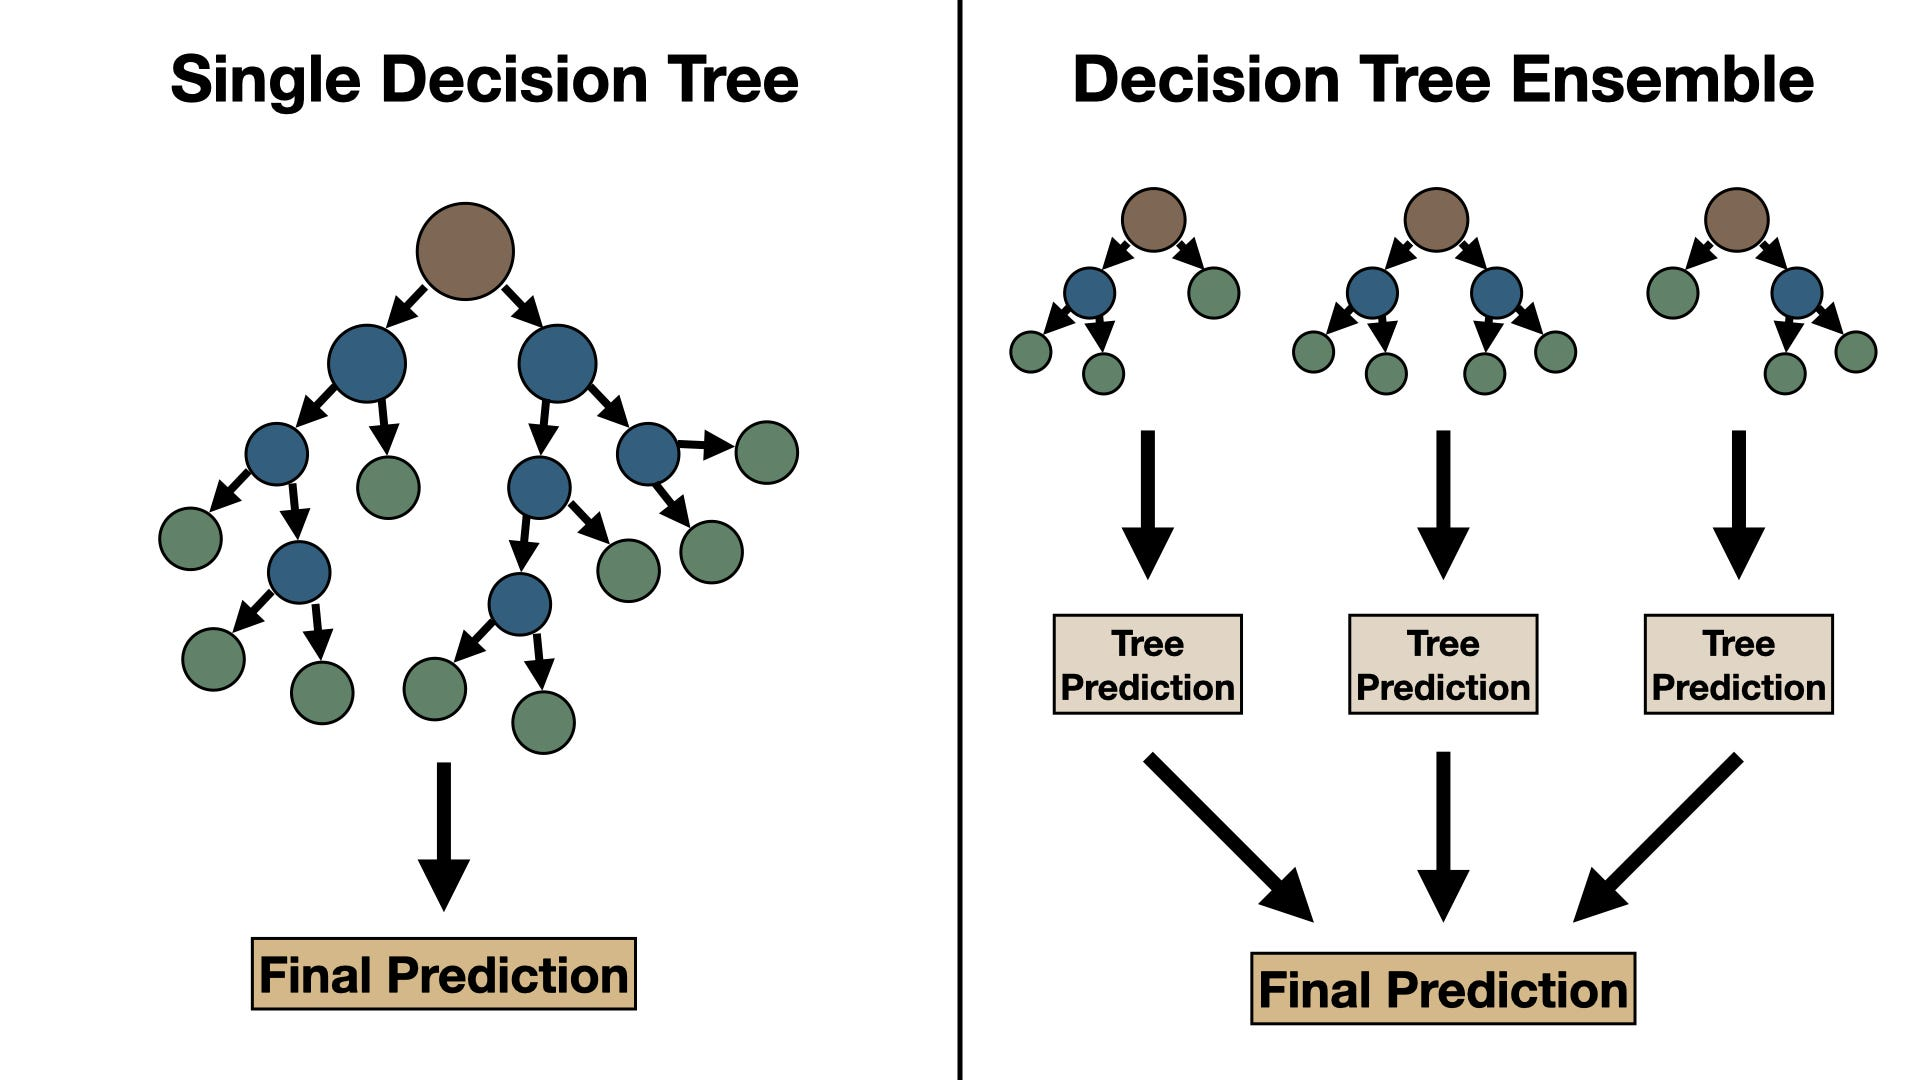

## **Number of Estimators and Features in Subsets**

### **How many decision trees should we use in total for the Random Forest?**

-   Intuitively, more trees offer more opportunities to learn from diverse feature subset combinations. Each tree, based on random sub-selection, will look different.

-   **Can large number of estimators  cause overfitting?**

    A crucial insight from Leo Breiman (the creator of Random Forests) is that **Random Forests do not overfit** as the number of trees increases. You can run as many trees as you want. As you add more estimators, the model's error will reduce and eventually plateau, but it will not start to increase again due to overfitting.

-   **Why no overfitting?**
  
     After a certain point, adding more trees means that new random selections are unlikely to reveal significantly *new* information. Newer trees become highly correlated to previously built trees, essentially producing duplicate or highly similar predictions. While this doesn't improve performance further (it hits an error threshold), it also doesn't lead to overfitting to the training data.

-   **Recommendation**:

    You can be quite lenient with this hyperparameter. A reasonable starting point (and Scikit-learn's default) is 100 estimators. You can then perform a grid search for higher values, or plot the error versus the number of trees to visually confirm where the error plateaus.

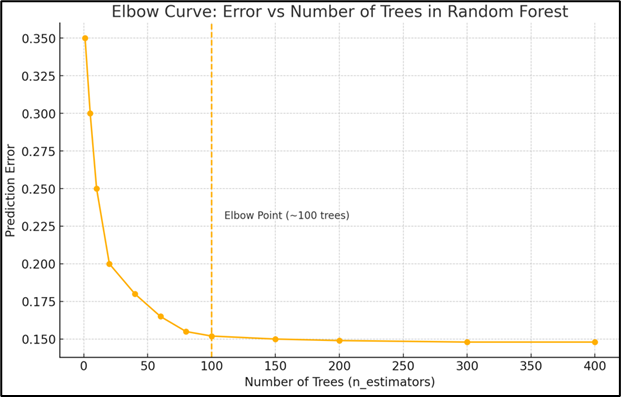

### **How many features out of the total `p` features should we include in each subset?**

-   The core idea is to introduce randomness by restricting the features available for splitting, ensuring that individual trees are diverse and less correlated.

-   **Effect on Tree Correlation**: If trees were allowed to consider all features at every split, they would likely be very similar, especially if a few features are highly predictive. By forcing each tree to consider only a random subset of features for each split, we reduce the correlation between individual trees, leading to a more robust ensemble.

-   **Breiman's Observation**: For classification tasks, the correlation between trees increases slowly as the number of features used increases. For regression tasks, it tends to increase faster. This implies that the optimal `max_features` might differ between these tasks.

-   **Common Starting Points**: Let `p` be the total number of features:
    -   **Classification**: $\sqrt{p}$ (a widely accepted convention).
    -   **Regression**: $p/3$ (empirically found to be more suitable, often larger than $\sqrt{p}$).
    -   **Original Publication**: $\log_2{(p)} + 1$.

-   **Recommendation**: Treat `max_features` as a crucial tuning parameter. The suggested values above are excellent starting points for a grid search. You will likely need to adjust this value (a little less or a little more) to optimize performance for your specific dataset.

<br><br>

## **Bootstrap Aggregation (Bagging)**

Bagging, or Bootstrap Aggregation, is an ensemble technique that combines predictions from multiple models trained on different subsets of the same dataset. It's a foundational component of Random Forests.

<br>

### **What is Bootstrapping?**

Bootstrapping is a resampling technique where you **sample with replacement** from an original dataset.

*   **Process**: Given an original dataset `D` of size `N` (number of rows/observations), we create multiple new datasets (e.g., `D1, D2, ..., DM`).
*   **Key Characteristic**: Each new dataset has the **same size `N` as the original**, but its samples are drawn **with replacement** from `D`. This means some original samples might appear multiple times in a bootstrapped dataset, while others might not appear at all.

<br>

### **Why is Bootstrapping Used in Random Forests?**

Bootstrapping is crucial for Random Forests because it helps create diverse individual decision trees, which is essential for the ensemble's strength.

*   **Diverse Data Views**: Each tree is trained on a slightly different version of the dataset, preventing them from becoming too similar.
*   **Reduces Correlation**: By seeing different samples, the individual trees make different errors, leading to less correlated predictions.
*   **Improves Generalization**: When these diverse (and less correlated) trees are aggregated, their individual weaknesses are compensated, resulting in a more robust and generalized model.

<br>

### **How Do Repeated Samples Affect the Model?**

The 'sampling with replacement' aspect of bootstrapping has several important consequences:

*   **Implicit Weighting**: Samples that appear multiple times in a bootstrapped dataset are implicitly given more importance, as the tree trained on that dataset will 'see' them more often. This introduces a form of random weighting on data points.
*   **Increased Tree Variability**: Because each bootstrapped dataset has different samples (some repeated, some missing), the individual decision trees built on them will develop different decision boundaries and learn distinct patterns. This variability is key to reducing the overall ensemble's variance.
*   **Reduced Overfitting (via Averaging)**: While individual trees might overfit to the specific repetitions and omissions in their bootstrapped datasets, the aggregation (e.g., averaging for regression, majority voting for classification) helps to cancel out these individual overfitting tendencies, preserving the consistent underlying signal.
*   **Creation of Out-of-Bag (OOB) Samples**: A significant consequence is that approximately one-third of the original data `D` will *not* be selected for any given bootstrapped dataset. These unselected samples are called **Out-of-Bag (OOB) samples**, and they serve as an internal validation set for that specific tree.

<br>



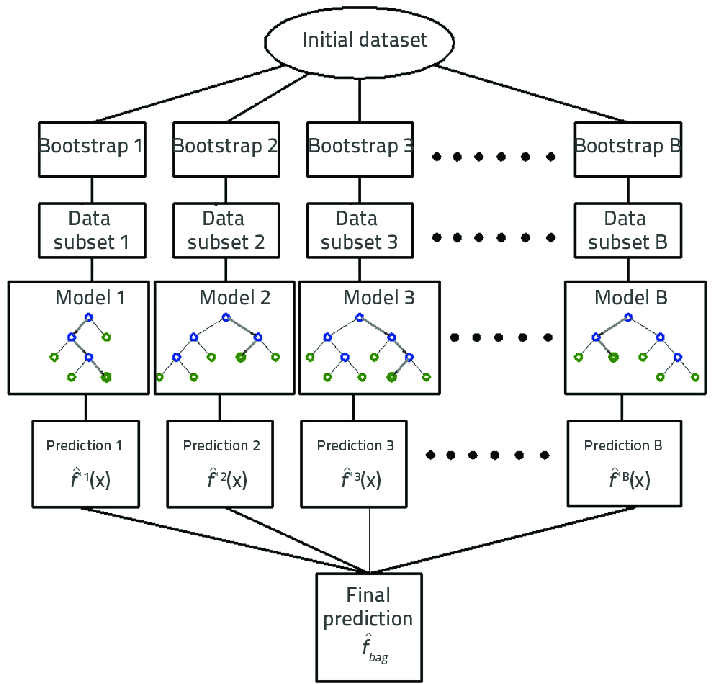

## **Out-of-Bag (OOB) Error**

- Each tree is trained on a bootstrap sample
- Each tree misses approximately 1/3 of data in other words 1/3 of data  is left out (not sampled)

    - Probability of NOT being selected in one draw with N samples: `(N-1)/N`
    - Probability of NOT being selected in N draws: `((N-1)/N)^N`
    - Taking the limit; as N (the number of samples in your dataset) becomes very large: `((N-1)/N)^N` --> 1/e
    - The Result: `e ~ 2.71828`  --> `1/e ~ 0.368` or about 36.8%

- These unused samples are called **Out-of-Bag samples**.

#### **OOB Error Estimation**

For each tree:
- Test on its OOB samples
- Aggregate errors across trees

#### **Advantages**

- No need for separate validation set
- Efficient internal performance estimate

#### **Limitation**

Not all trees are used for each sample → less robust than full test evaluation



<br>

## **Key Hyperparameters**

- **Number of Trees ($M$)**

  - Controls number of estimators
  - Behavior: Error decreases as M increases
  - Eventually plateaus (no overfitting spike)

- **Number of Features per Split ($m$)**

  - Let total features = p
  - Common choices:
      - Classification: $m = \sqrt p$
      - Regression: $m = \frac{p}{3}$
      - Alternative: $m = \log_{2}{(p)} + 1$

- **Bootstrapping**

  - bootstrap = True (default)
  - Enables sampling with replacement

- **OOB Score**

  - oob_score = True/False
  - Computes out-of-bag error
  - Does not affect training, only evaluation

- **Tree-specific Parameters**

  Inherited from decision trees:
    - max_depth
    - min_samples_split
    - min_samples_leaf

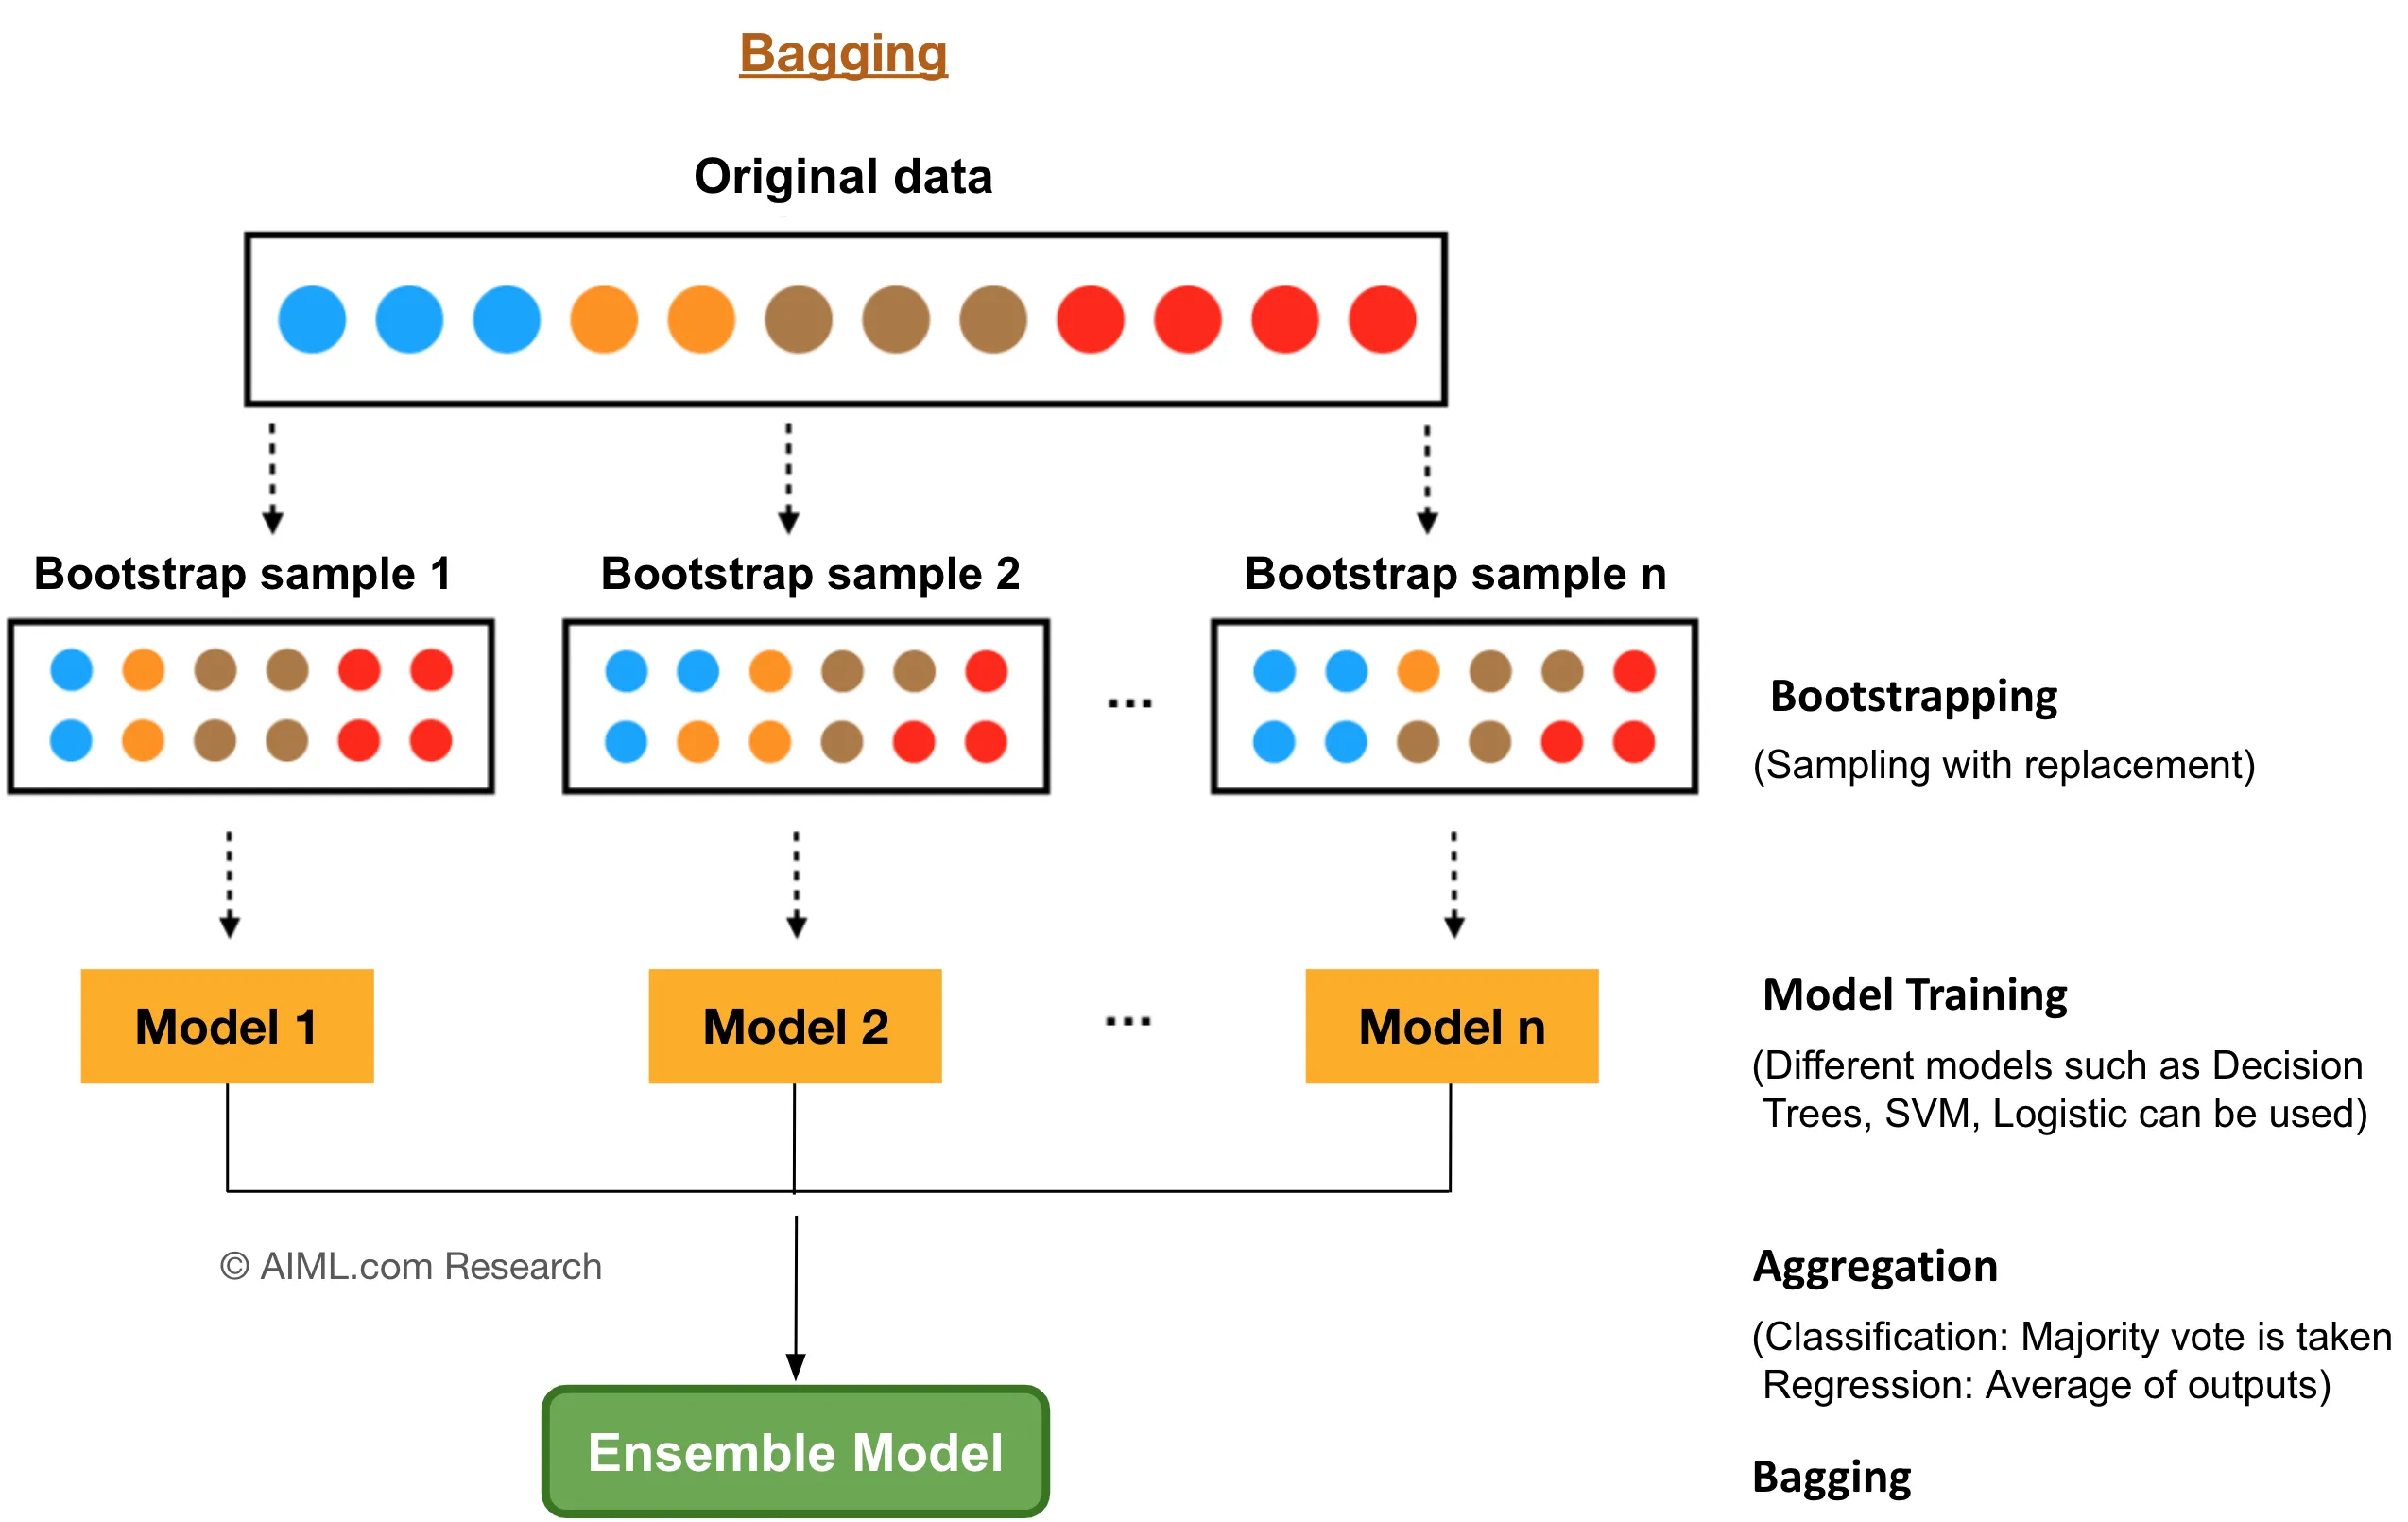

<br><br>

# **Random Forest Classification Implementation**

The dataset we are using is the **Wisconsin Breast Cancer Diagnostic dataset**, which is a classic dataset for binary classification tasks. It contains **569 rows (samples)** and **30 numerical features** computed from digitized images of fine needle aspirate (FNA) of a breast mass. These features describe characteristics of the cell nuclei present in the image, such as `mean radius`, `mean texture`, `mean perimeter`, and `mean area`.

Our **target variable** (`target`) represents the diagnosis, where `0` typically indicates a malignant (cancerous) tumor and `1` indicates a benign (non-cancerous) tumor.

Our task is to build a **Random Forest Classification model** to predict whether a tumor is **malignant (cancerous)** or **benign (non-cancerous)** based on these features. This will demonstrate the application of Random Forests for a real-world classification problem.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

## **Dataset & EDA**

In [ ]:
# Load dataset
breast = load_breast_cancer()

X = breast.data
y = breast.target

In [ ]:
df = pd.DataFrame(X, columns=breast.feature_names)

df["target"] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df["target"].value_counts()

,count
target,
1,357
0,212


<Axes: title={'center': 'Breast Cancer Classes'}, xlabel='Class', ylabel='Count'>

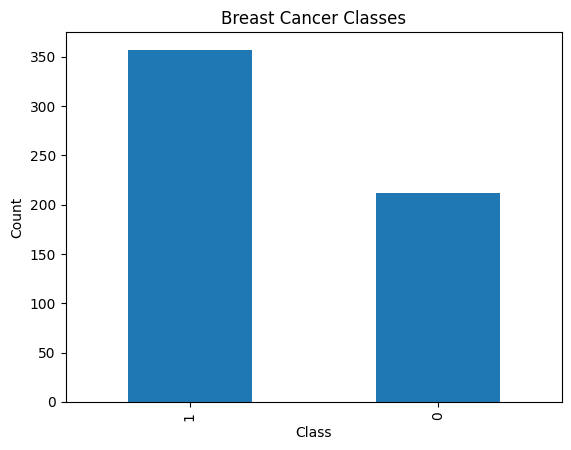

In [ ]:
df["target"].value_counts().plot(
    kind="bar",
    xlabel="Class",
    ylabel="Count",
    title="Breast Cancer Classes"
)

In [ ]:
corr = df.corr()

corr.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560


Text(0.5, 1.0, 'Correlation Matrix')

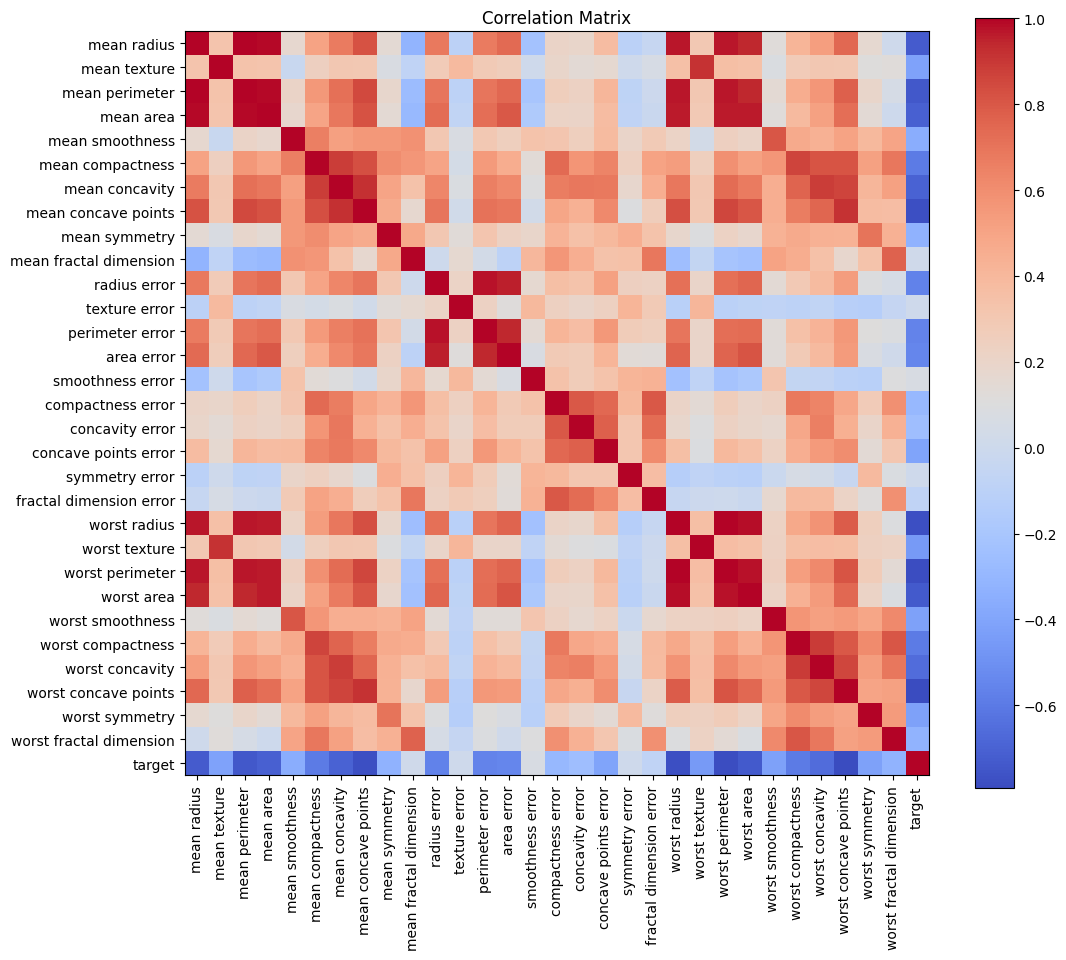

In [ ]:
plt.figure(figsize=(12,10))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")

## **Train | Test Split**

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## **Train a Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
tree_predictions = tree.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, tree_predictions)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, tree_predictions)

print(cm)

[[40  3]
 [ 3 68]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, tree_predictions))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



[Text(0.6145833333333334, 0.9375, 'mean concave points <= 0.051\ngini = 0.467\nsamples = 455\nvalue = [169, 286]\nclass = Benign'),
 Text(0.3958333333333333, 0.8125, 'worst radius <= 16.83\ngini = 0.107\nsamples = 282\nvalue = [16, 266]\nclass = Benign'),
 Text(0.5052083333333334, 0.875, 'True  '),
 Text(0.2916666666666667, 0.6875, 'area error <= 48.7\ngini = 0.037\nsamples = 263\nvalue = [5, 258]\nclass = Benign'),
 Text(0.20833333333333334, 0.5625, 'worst smoothness <= 0.178\ngini = 0.023\nsamples = 260\nvalue = [3, 257]\nclass = Benign'),
 Text(0.16666666666666666, 0.4375, 'smoothness error <= 0.003\ngini = 0.015\nsamples = 259\nvalue = [2, 257]\nclass = Benign'),
 Text(0.08333333333333333, 0.3125, 'worst texture <= 27.755\ngini = 0.245\nsamples = 7\nvalue = [1, 6]\nclass = Benign'),
 Text(0.041666666666666664, 0.1875, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]\nclass = Benign'),
 Text(0.125, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = Malignant'),
 Text(0.25, 0.3125, 'w

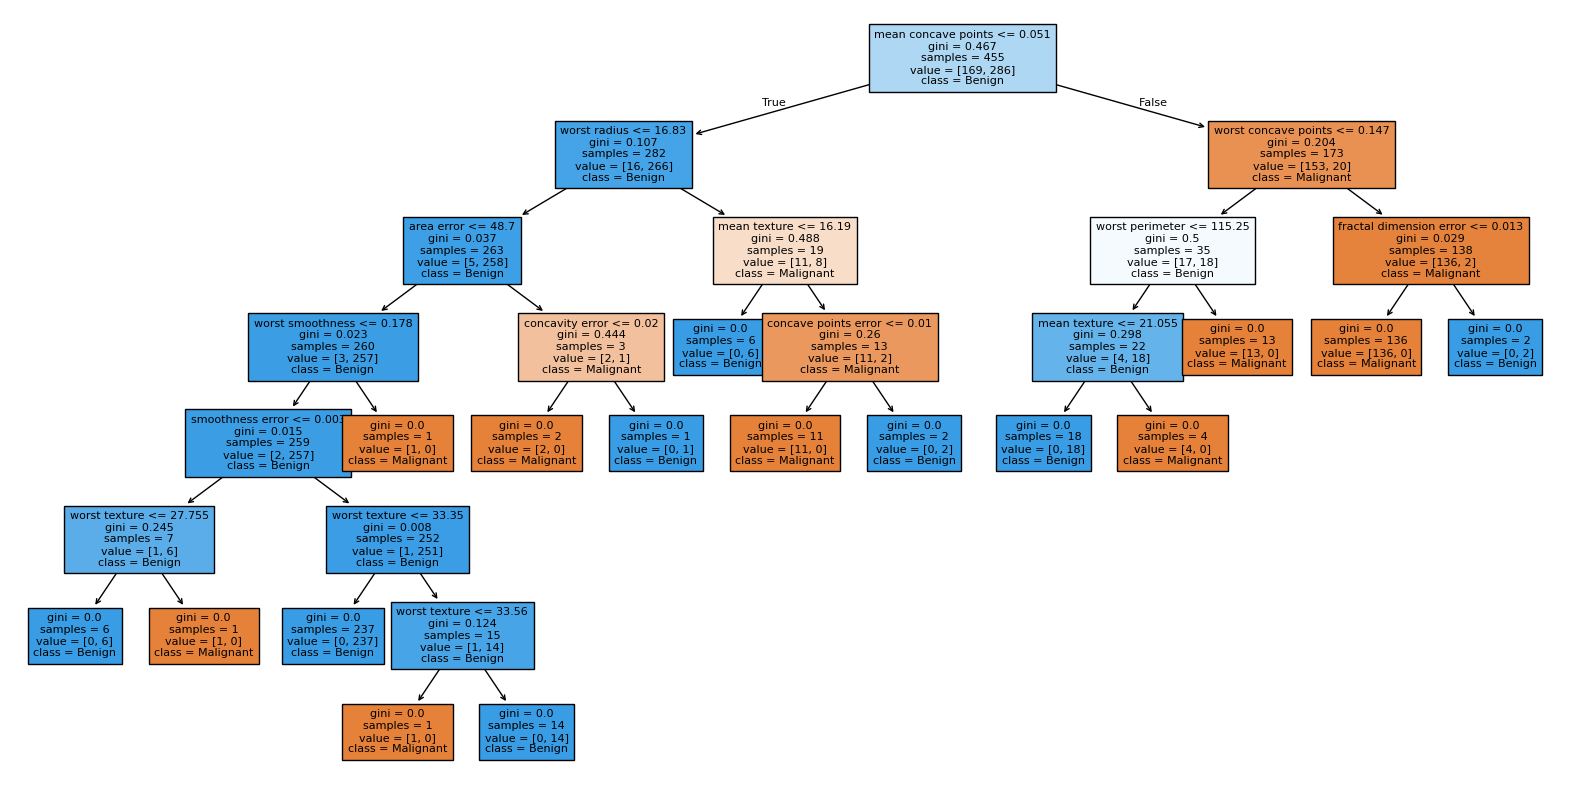

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Malignant","Benign"],
    filled=True,
    fontsize=8
)

## **Train a Random Forest**


In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100,random_state=42)

forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
forest_predictions = forest.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, forest_predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [ ]:
cm = confusion_matrix(y_test, forest_predictions)
print(cm)

[[40  3]
 [ 1 70]]


In [ ]:
print(classification_report(y_test, forest_predictions))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## **Compare Models**

In [ ]:
tree_accuracy = accuracy_score(y_test, tree_predictions)
forest_accuracy = accuracy_score(y_test, forest_predictions)

comparison = pd.DataFrame({
    "Model":["Decision Tree","Random Forest"],
    "Accuracy":[tree_accuracy, forest_accuracy]
})

comparison

,Model,Accuracy
0,Decision Tree,0.947368
1,Random Forest,0.964912


## **Feature Importance**

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
23,worst area,0.153892
27,worst concave points,0.144663
7,mean concave points,0.106210
20,worst radius,0.077987
6,mean concavity,0.068001
22,worst perimeter,0.067115
2,mean perimeter,0.053270
0,mean radius,0.048703
3,mean area,0.047555
26,worst concavity,0.031802


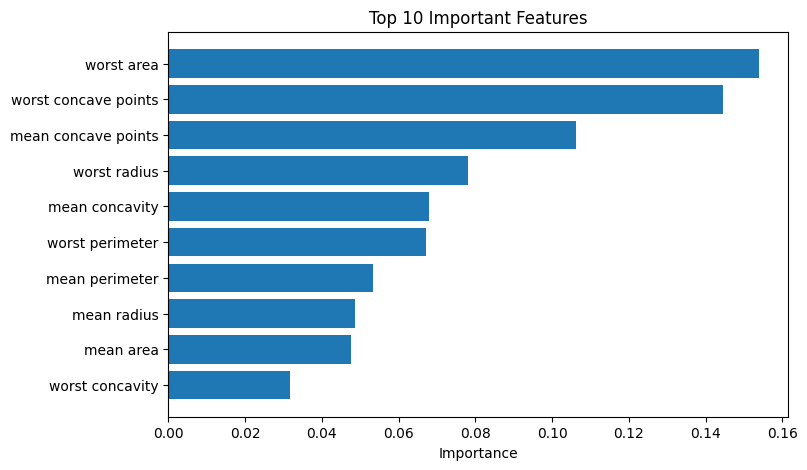

In [ ]:
top = importance.head(10)
plt.figure(figsize=(8,5))
plt.barh(top["Feature"], top["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(n_estimators=1)
model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=1)

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

predictions = model.predict(X_test)

In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        43
           1       0.94      0.89      0.91        71

    accuracy                           0.89       114
   macro avg       0.89      0.90      0.89       114
weighted avg       0.90      0.89      0.90       114



In [ ]:
model.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
model.feature_importances_.argmax()

np.int64(7)

In [ ]:
X.columns[7]

'mean concave points'

<Axes: xlabel='target', ylabel='count'>

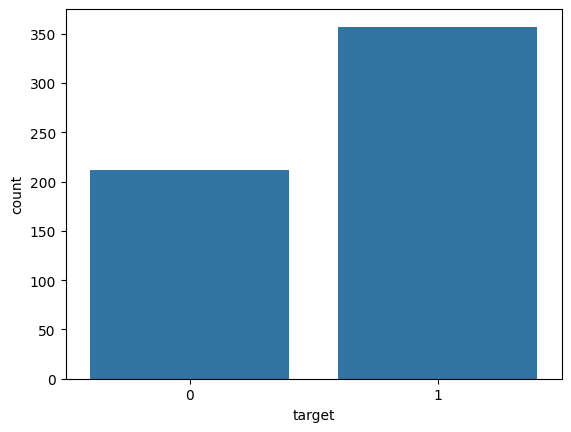

In [ ]:
import seaborn as sns
sns.countplot(data=df,x='target')

In [ ]:
len(X.columns)

30

In [ ]:
error_rates = []

for n in range(1,30):

    model = AdaBoostClassifier(n_estimators=n)
    model.fit(X_train,y_train)
    preds = model.predict(X_test)
    err = 1 - accuracy_score(y_test,preds)

    error_rates.append(err)

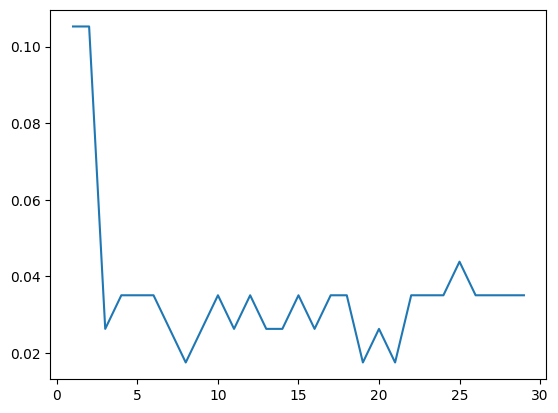

In [ ]:
plt.plot(range(1,30),error_rates)

In [ ]:
model

AdaBoostClassifier(n_estimators=29)

In [ ]:
model.feature_importances_

array([0.        , 0.07163882, 0.        , 0.        , 0.02927173,
       0.        , 0.        , 0.12299289, 0.05737361, 0.02128513,
       0.027163  , 0.        , 0.        , 0.06560197, 0.        ,
       0.06357932, 0.        , 0.        , 0.03766196, 0.        ,
       0.        , 0.09960906, 0.        , 0.15433559, 0.03205086,
       0.        , 0.03241312, 0.09084561, 0.09417733, 0.        ])

In [ ]:
feats = pd.DataFrame(index=X.columns,data=model.feature_importances_,columns=['Importance'])

In [ ]:
feats

,Importance
mean radius,0.000000
mean texture,0.071639
mean perimeter,0.000000
mean area,0.000000
mean smoothness,0.029272
mean compactness,0.000000
mean concavity,0.000000
mean concave points,0.122993
mean symmetry,0.057374
mean fractal dimension,0.021285


In [ ]:
imp_feats = feats[feats['Importance']>0]
imp_feats

,Importance
mean texture,0.071639
mean smoothness,0.029272
mean concave points,0.122993
mean symmetry,0.057374
mean fractal dimension,0.021285
radius error,0.027163
area error,0.065602
compactness error,0.063579
symmetry error,0.037662
worst texture,0.099609


In [ ]:
imp_feats = imp_feats.sort_values("Importance")

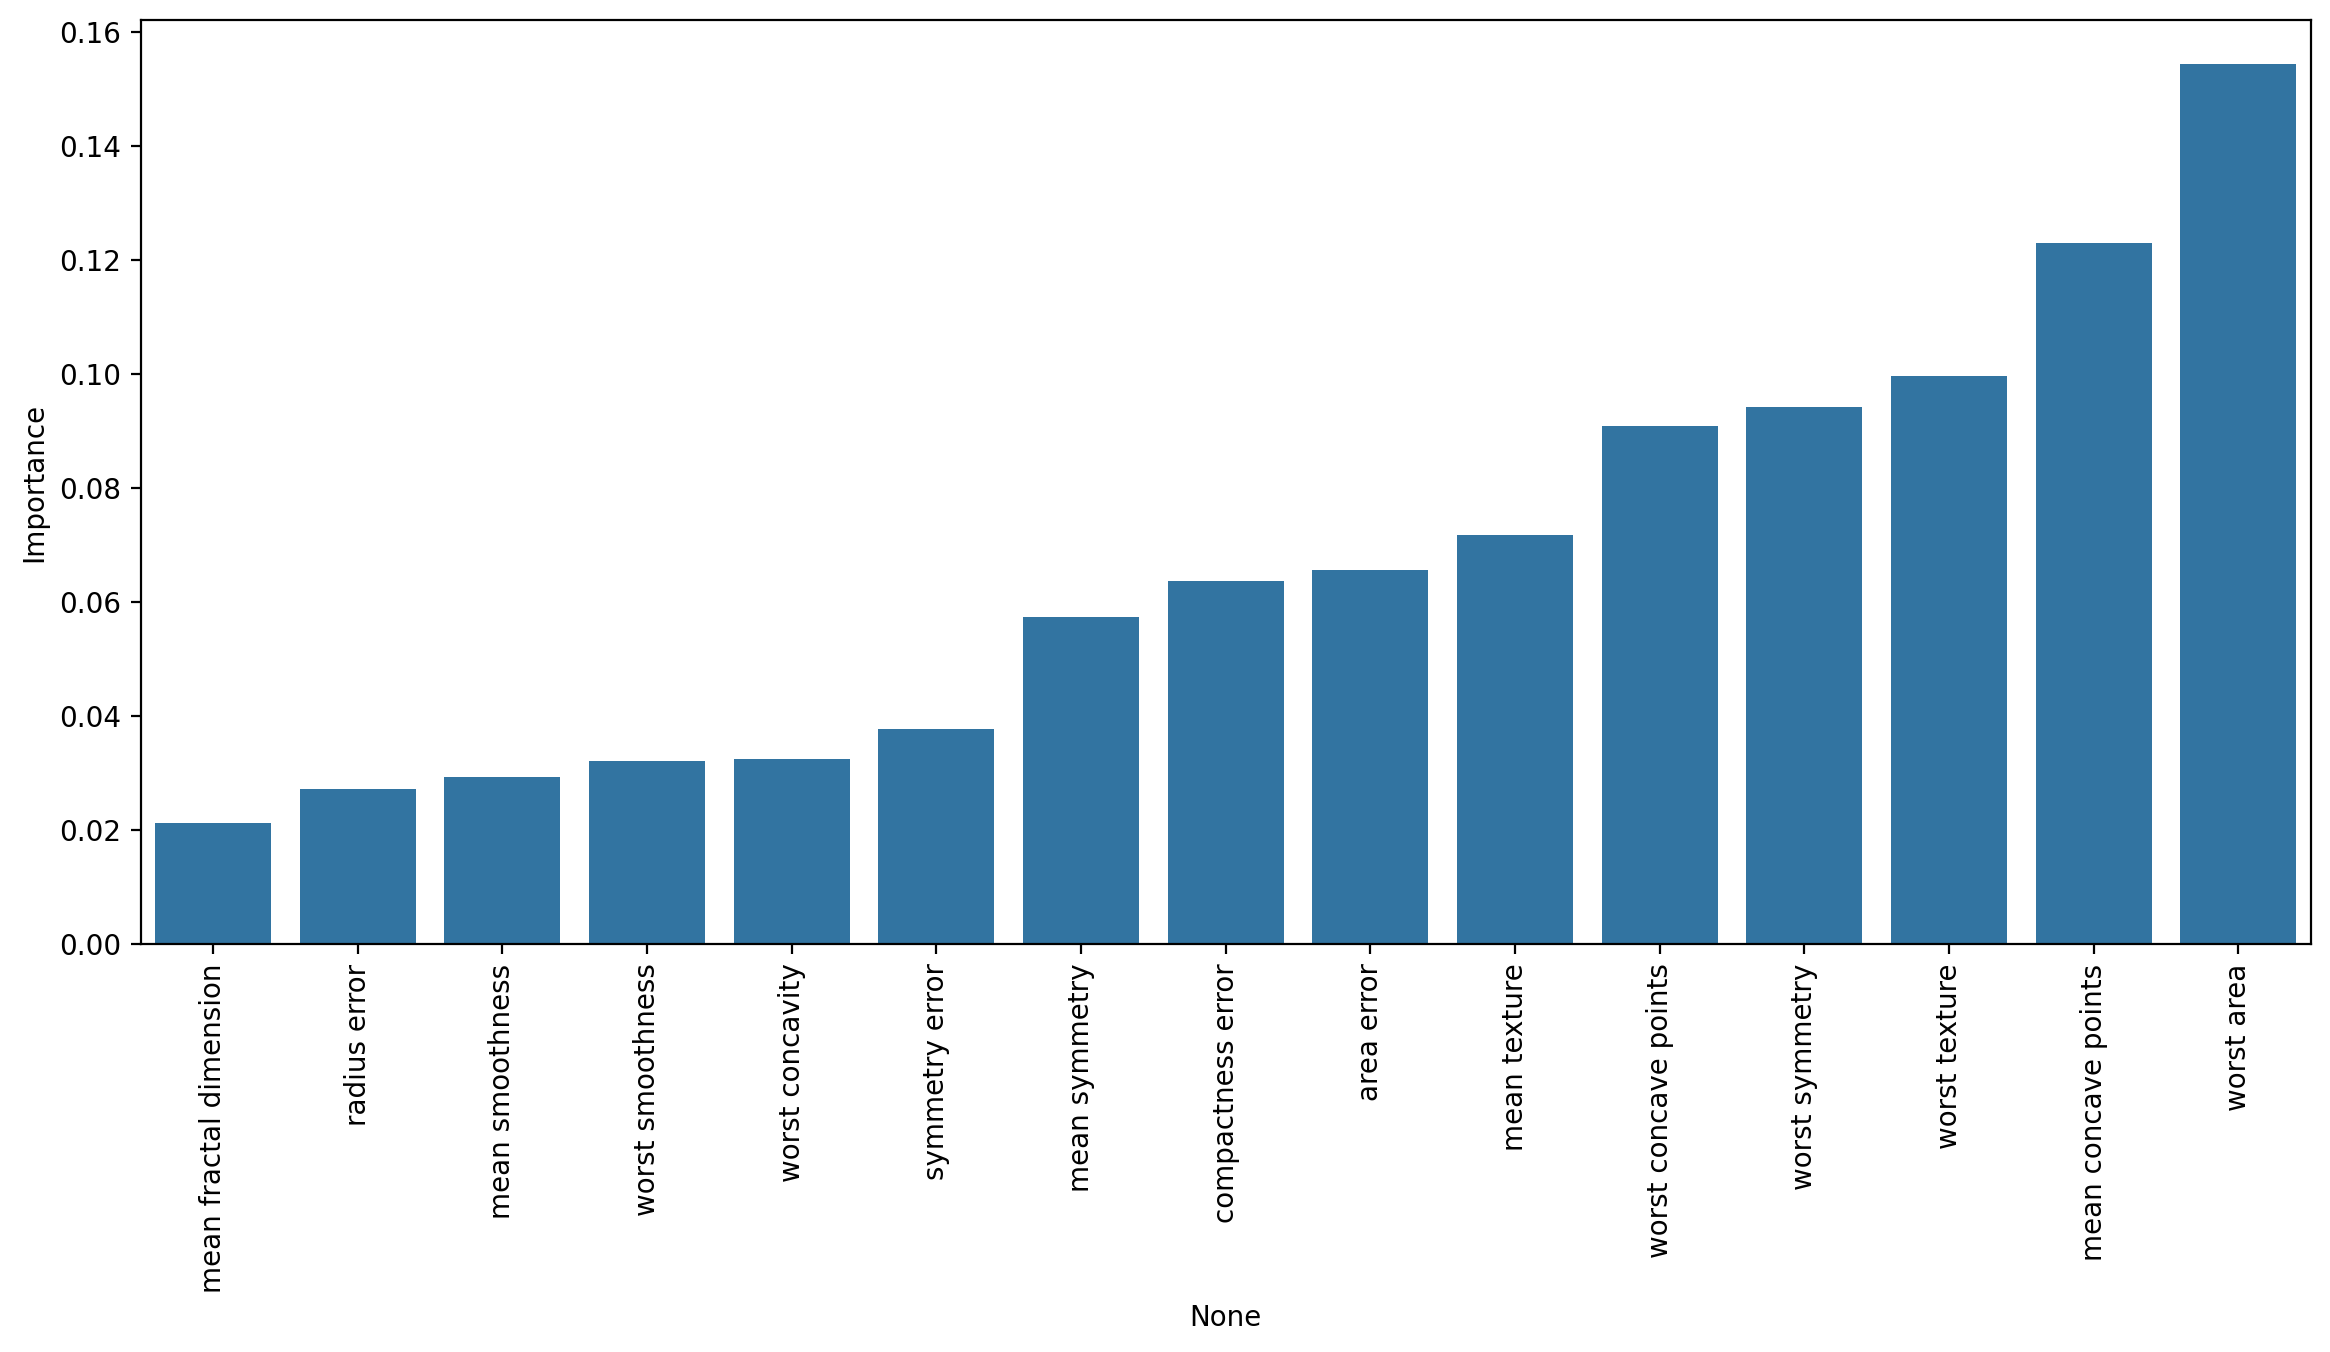

In [ ]:
plt.figure(figsize=(14,6),dpi=200)
sns.barplot(data=imp_feats.sort_values('Importance'),x=imp_feats.sort_values('Importance').index,y='Importance')

plt.xticks(rotation=90);

In [ ]:
predictions = model.predict(X_test)
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

